## Name : Rajkumar Rajak
## Scholar No : 25215011118

## Lab 6 : Denoising autoencoder on FashionMNIST dataset

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

Device: cpu


100%|██████████| 26.4M/26.4M [00:02<00:00, 10.7MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 169kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.14MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 10.0MB/s]


Training images loaded: 60000
Training started...


Epoch 1: 100%|██████████| 469/469 [00:46<00:00, 10.04it/s, loss=0.00795]


Epoch 1 Loss: 0.0171


...

Epoch 8 Loss: 0.0062


Epoch 9: 100%|██████████| 469/469 [00:47<00:00,  9.94it/s, loss=0.00601]


Epoch 9 Loss: 0.0061


Epoch 10: 100%|██████████| 469/469 [00:47<00:00,  9.89it/s, loss=0.00589]


Epoch 10 Loss: 0.0061


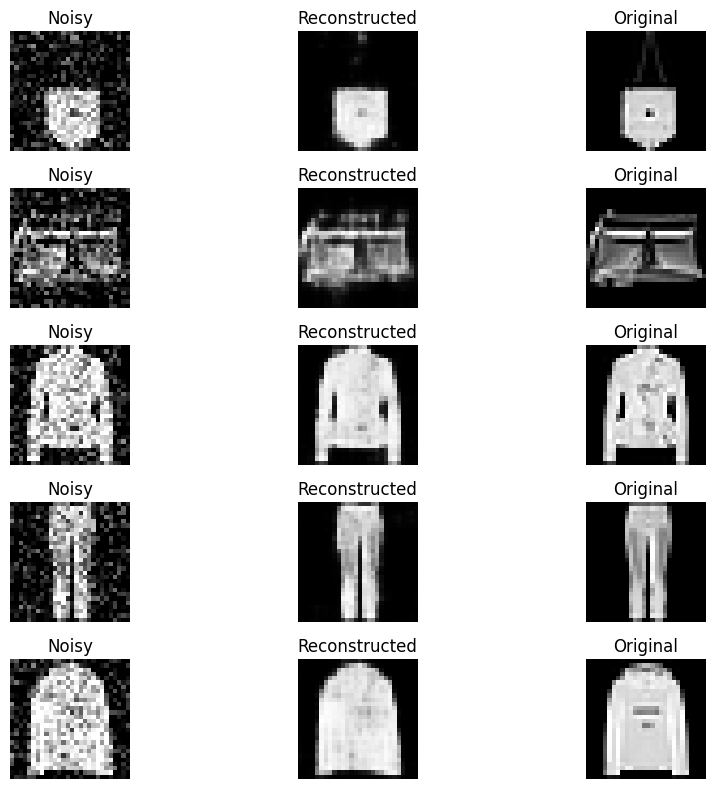

In [2]:
import os, cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

IMG_SIZE = 28
BATCH_SIZE = 128
EPOCHS = 10
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)

transform = transforms.ToTensor()

train_dataset = datasets.FashionMNIST(
    root="./data", train=True, download=True, transform=transform)

test_dataset = datasets.FashionMNIST(
    root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=10, shuffle=True)

print("Training images loaded:", len(train_dataset))

def add_noise(img, noise_factor=0.2):
    noise = torch.randn_like(img) * noise_factor
    noisy = img + noise
    return torch.clamp(noisy, 0., 1.)

class DAE(nn.Module):
    def __init__(self):
        super(DAE, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 3, stride=2, padding=1),  # 28→14
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1), # 14→7
            nn.ReLU()
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, 3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

model = DAE().to(DEVICE)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print("Training started...")

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0

    loop = tqdm(train_loader)
    for images, _ in loop:
        images = images.to(DEVICE)
        noisy_images = add_noise(images).to(DEVICE)

        outputs = model(noisy_images)
        loss = criterion(outputs, images)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        loop.set_description(f"Epoch {epoch+1}")
        loop.set_postfix(loss=loss.item())

    print(f"Epoch {epoch+1} Loss: {running_loss/len(train_loader):.4f}")

model.eval()

images, _ = next(iter(test_loader))
noisy = add_noise(images)

images = images.to(DEVICE)
noisy = noisy.to(DEVICE)

with torch.no_grad():
    outputs = model(noisy)

images = images.cpu().numpy()
noisy = noisy.cpu().numpy()
outputs = outputs.cpu().numpy()

plt.figure(figsize=(10,8))

for i in range(5):
    # Noisy
    plt.subplot(5,3,3*i+1)
    plt.imshow(noisy[i].squeeze(), cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

    # Reconstructed
    plt.subplot(5,3,3*i+2)
    plt.imshow(outputs[i].squeeze(), cmap='gray')
    plt.title("Reconstructed")
    plt.axis('off')

    # Original
    plt.subplot(5,3,3*i+3)
    plt.imshow(images[i].squeeze(), cmap='gray')
    plt.title("Original")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [3]:
test_loss = 0

model.eval()
with torch.no_grad():
    for images, _ in test_loader:
        images = images.to(DEVICE)
        noisy = add_noise(images).to(DEVICE)

        outputs = model(noisy)
        loss = criterion(outputs, images)

        test_loss += loss.item()

test_loss /= len(test_loader)
print(f"Test Loss (MSE): {test_loss:.4f}")

Test Loss (MSE): 0.0061
